In [1]:
# import os
# import subprocess
# import sys

# # 基础目录（Windows，本地存储不再用 temp）
# base_dir = "C:/Users/kelvin/Downloads/brats_workspace"
# working_dir = os.path.join(base_dir, "working")
# models_dir = os.path.join(working_dir, "kaist_models")
# os.makedirs(models_dir, exist_ok=True)

# # Install necessary packages
# try:
#     subprocess.check_call([sys.executable, "-m", "pip", "-q", "install", "gdown", "patool"])
# except subprocess.CalledProcessError as e:
#     print(f"Error installing packages: {e}")

# # Download the model
# model_rar_path = os.path.join(models_dir, "brats21_trained_models.rar")
# try:
#     print("Downloading model...")
#     subprocess.run([
#         "gdown", "--id", "1HZmWG4j2zQg0vVwBsTrpnuLOmtKCpix2",
#         "-O", model_rar_path
#     ], check=True)
#     print("Model downloaded.")
# except (subprocess.CalledProcessError, FileNotFoundError) as e:
#     print(f"Error downloading model: {e}")

# # Extract the model
# # Note: This requires the 'unrar' command-line tool to be installed and in the system's PATH.
# if os.path.exists(model_rar_path):
#     try:
#         import patoolib
#         print("Extracting model...")
#         patoolib.extract_archive(model_rar_path, outdir=models_dir)
#         print("Model extracted.")
#     except Exception as e:
#         print(f"Error extracting archive: {e}")
#         print("Please ensure the 'unrar' command-line tool is installed and in your system's PATH.")

# print("Setup complete.")

In [1]:
!pip -q install nnunet==1.7.1 SimpleITK nibabel

import os, glob, json, tarfile
import numpy as np
import nibabel as nib
import SimpleITK as sitk
from tqdm.notebook import tqdm

print("nnU-Net installed.")


nnU-Net installed.


In [2]:
base_dir = "C:/Users/kelvin/Downloads/brats_workspace"
RESULTS_FOLDER = os.path.join(base_dir, "working", "kaist_models", "trained_models")

# 使用非 temp 路径（Windows）
os.environ["nnUNet_raw_data_base"] = os.path.join(base_dir, "nnunet_raw_base")
os.environ["nnUNet_preprocessed"] = os.path.join(base_dir, "nnunet_preprocessed")
os.environ["RESULTS_FOLDER"] = RESULTS_FOLDER

# 确保目录存在
os.makedirs(os.environ["nnUNet_raw_data_base"], exist_ok=True)
os.makedirs(os.environ["nnUNet_preprocessed"], exist_ok=True)

print("nnUNet_raw_data_base =", os.environ["nnUNet_raw_data_base"])
print("nnUNet_preprocessed =", os.environ["nnUNet_preprocessed"])
print("RESULTS_FOLDER =", os.environ["RESULTS_FOLDER"])

nnUNet_raw_data_base = C:/Users/kelvin/Downloads/brats_workspace\nnunet_raw_base
nnUNet_preprocessed = C:/Users/kelvin/Downloads/brats_workspace\nnunet_preprocessed
RESULTS_FOLDER = C:/Users/kelvin/Downloads/brats_workspace\working\kaist_models\trained_models


In [3]:
import os, glob, shutil
from tqdm.notebook import tqdm

# 数据所在目录（Windows）：解压后的 BraTS2021_Training_Data 内包含 BraTS2021_xxxxx 子目录
DATA_DIR = "C:/Users/kelvin/Downloads/archive/BraTS2021_Training_Data"
NN_INPUT_DIR = "C:/Users/kelvin/Downloads/brats_workspace/nnunet_inputs"

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(NN_INPUT_DIR, exist_ok=True)

# Data is already extracted in DATA_DIR

cases = sorted([d for d in os.listdir(DATA_DIR) if d.startswith("BraTS2021_") and os.path.isdir(os.path.join(DATA_DIR, d))])
mods = ["t1","t1ce","t2","flair"]

def prepare_nnunet_inputs():
    for pid in tqdm(cases):
        cdir = os.path.join(DATA_DIR, pid)
        for ch, m in enumerate(mods):
            src = os.path.join(cdir, f"{pid}_{m}.nii.gz")
            dst = os.path.join(NN_INPUT_DIR, f"{pid}_{ch:04d}.nii.gz")
            if not os.path.exists(src):
                raise FileNotFoundError(f"missing modality file: {src}")
            if not os.path.exists(dst):
                shutil.copy(src, dst)

prepare_nnunet_inputs()
print("prepared inputs:", len(glob.glob(os.path.join(NN_INPUT_DIR, "*.nii.gz"))))

  0%|          | 0/1251 [00:00<?, ?it/s]

prepared inputs: 5004


In [4]:
import os, glob

base_dir = "C:/Users/kelvin/Downloads/brats_workspace"
WEIGHTS_BASE = os.path.join(base_dir, "working", "kaist_models")

print("Listing possible nnUNet roots under:", WEIGHTS_BASE)
cands = glob.glob(os.path.join(WEIGHTS_BASE, "**/nnUNet/3d_fullres/Task*"), recursive=True)

if len(cands) == 0:
    raise RuntimeError("❌ Did not find nnUNet/3d_fullres/Task* under kaist_models. Please check extract path.")
else:
    print("✅ Found tasks:")
    for p in cands[:10]:
        print("  ", p)

# 自动取 Task* 的上上级作为 RESULTS_FOLDER
# .../RESULTS_FOLDER/nnUNet/3d_fullres/TaskXXX_...
RESULTS_FOLDER = cands[0].split("/nnUNet/3d_fullres/")[0]
print("\nAuto-detected RESULTS_FOLDER =")
print(RESULTS_FOLDER)

Listing possible nnUNet roots under: C:/Users/kelvin/Downloads/brats_workspace\working\kaist_models
✅ Found tasks:
   C:/Users/kelvin/Downloads/brats_workspace\working\kaist_models\trained_models\nnUNet\3d_fullres\Task500_BraTS2021

Auto-detected RESULTS_FOLDER =
C:/Users/kelvin/Downloads/brats_workspace\working\kaist_models\trained_models\nnUNet\3d_fullres\Task500_BraTS2021


In [5]:
import os, glob

base_dir = "C:/Users/kelvin/Downloads/brats_workspace"
TASK_DIR = os.path.join(base_dir, "working", "kaist_models", "trained_models", "nnUNet", "3d_fullres", "Task500_BraTS2021")

print("Task dir:", TASK_DIR)
print("\nSubfolders under task:")
subs = sorted([d for d in os.listdir(TASK_DIR) if os.path.isdir(os.path.join(TASK_DIR, d))])
for s in subs:
    print("  ", s)

# 找到类似 nnUNetTrainerXXX__nnUNetPlansYYY 的文件夹
model_folders = [s for s in subs if "__" in s]
if len(model_folders) == 0:
    raise RuntimeError("❌ No trainer__plans folder found. Paste the folder list here.")

print("\n Candidate model folders:")
for s in model_folders:
    print("  ", s)

# 取第一个当默认（通常就一个）
MODEL_FOLDER = model_folders[0]
trainer_name, plans_name = MODEL_FOLDER.split("__", 1)

print("\nAuto-detected:")
print("  trainer_name =", trainer_name)
print("  plans_name   =", plans_name)

# 再确认 fold 目录
folds = sorted(glob.glob(os.path.join(TASK_DIR, MODEL_FOLDER, "fold_*")))
print("\nFolds found:", [os.path.basename(f) for f in folds])

Task dir: C:/Users/kelvin/Downloads/brats_workspace\working\kaist_models\trained_models\nnUNet\3d_fullres\Task500_BraTS2021

Subfolders under task:
   nnUNetTrainerV2BraTSRegions_DA4_BN_BD__nnUNetPlansv2.1
   nnUNetTrainerV2BraTSRegions_DA4_BN_BD_largeUnet_Groupnorm__nnUNetPlansv2.1

 Candidate model folders:
   nnUNetTrainerV2BraTSRegions_DA4_BN_BD__nnUNetPlansv2.1
   nnUNetTrainerV2BraTSRegions_DA4_BN_BD_largeUnet_Groupnorm__nnUNetPlansv2.1

Auto-detected:
  trainer_name = nnUNetTrainerV2BraTSRegions_DA4_BN_BD
  plans_name   = nnUNetPlansv2.1

Folds found: ['fold_0', 'fold_1', 'fold_2', 'fold_3', 'fold_4']


In [6]:
os.environ["TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD"] = "1"

print("Set TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD=1")


Set TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD=1


In [7]:
import os, shutil, subprocess, glob
from tqdm.notebook import tqdm

base_dir = r"C:\Users\kelvin\Downloads\brats_workspace"

# ====== 路径 ======
DATA_DIR      = r"C:\Users\kelvin\Downloads\archive\BraTS2021_Training_Data"
NN_INPUT_BASE = os.path.join(base_dir, "nnunet_inputs")
OUT_DIR       = os.path.join(base_dir, "kaist_pred_A")
TMP_IN_DIR    = os.path.join(base_dir, "tmp_nnunet_in")
TMP_OUT_DIR   = os.path.join(base_dir, "tmp_nnunet_out")
LOG_DIR       = os.path.join(base_dir, "logs_nnunet_predict")

TASK_NAME   = "Task500_BraTS2021"
trainer_A   = "nnUNetTrainerV2BraTSRegions_DA4_BN_BD"
plans_name  = "nnUNetPlansv2.1"

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(TMP_IN_DIR, exist_ok=True)
os.makedirs(TMP_OUT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

# ====== 固定 env + cwd（避免子进程相对路径/torch加载问题） ======
env = os.environ.copy()
env["TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD"] = "1"
env["OMP_NUM_THREADS"] = "1"
env["MKL_NUM_THREADS"] = "1"
env["CUDA_VISIBLE_DEVICES"] = "0"   # 可选：更稳

CWD = base_dir  # 固定工作目录

# ====== 控制推理数量 ======
cases = sorted([d for d in os.listdir(DATA_DIR) if d.startswith("BraTS2021_")])
N_RUN = 100
cases_run = cases[:N_RUN]
print("Will run cases:", cases_run)

# ====== 逐 case 推理 ======
for pid in tqdm(cases_run, desc="nnU-Net inference"):
    shutil.rmtree(TMP_IN_DIR, ignore_errors=True)
    shutil.rmtree(TMP_OUT_DIR, ignore_errors=True)
    os.makedirs(TMP_IN_DIR, exist_ok=True)
    os.makedirs(TMP_OUT_DIR, exist_ok=True)

    for ch in range(4):
        src = os.path.join(NN_INPUT_BASE, f"{pid}_{ch:04d}.nii.gz")
        dst = os.path.join(TMP_IN_DIR, f"{pid}_{ch:04d}.nii.gz")
        if not os.path.exists(src):
            raise FileNotFoundError(f"Missing modality file: {src}")
        shutil.copy(src, dst)

    cmd = [
        "nnUNet_predict",
        "-i", TMP_IN_DIR,
        "-o", TMP_OUT_DIR,
        "-t", TASK_NAME,
        "-tr", trainer_A,
        "-p", plans_name,
        "-m", "3d_fullres",
        "-f", "0",
        "--num_threads_preprocessing", "1",
        "--num_threads_nifti_save", "1",
        "--disable_tta",
        "--overwrite_existing",
    ]

    print("Running:", " ".join(cmd))
    result = subprocess.run(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
        env=env,
        cwd=CWD
    )

    log_out = os.path.join(LOG_DIR, f"{pid}.stdout.txt")
    log_err = os.path.join(LOG_DIR, f"{pid}.stderr.txt")
    open(log_out, "w", encoding="utf-8", errors="ignore").write(result.stdout)
    open(log_err, "w", encoding="utf-8", errors="ignore").write(result.stderr)

    print(f"Saved logs:\n  {log_out}\n  {log_err}")
    print("--- stderr tail ---\n", result.stderr[-2000:])

    if result.returncode != 0:
        raise RuntimeError(
            f"nnUNet_predict failed with code {result.returncode}.\n"
            f"Check logs:\n  {log_out}\n  {log_err}"
        )

    pred_path = os.path.join(TMP_OUT_DIR, f"{pid}.nii.gz")
    if not os.path.exists(pred_path):
        raise FileNotFoundError(f"Prediction not found: {pred_path}")
    shutil.move(pred_path, os.path.join(OUT_DIR, f"{pid}.nii.gz"))

print("Done. Predicted:", len(glob.glob(os.path.join(OUT_DIR, "BraTS2021_*.nii.gz"))))


Will run cases: ['BraTS2021_00000', 'BraTS2021_00002', 'BraTS2021_00003', 'BraTS2021_00005', 'BraTS2021_00006', 'BraTS2021_00008', 'BraTS2021_00009', 'BraTS2021_00011', 'BraTS2021_00012', 'BraTS2021_00014', 'BraTS2021_00016', 'BraTS2021_00017', 'BraTS2021_00018', 'BraTS2021_00019', 'BraTS2021_00020', 'BraTS2021_00021', 'BraTS2021_00022', 'BraTS2021_00024', 'BraTS2021_00025', 'BraTS2021_00026', 'BraTS2021_00028', 'BraTS2021_00030', 'BraTS2021_00031', 'BraTS2021_00032', 'BraTS2021_00033', 'BraTS2021_00035', 'BraTS2021_00036', 'BraTS2021_00043', 'BraTS2021_00044', 'BraTS2021_00045', 'BraTS2021_00046', 'BraTS2021_00048', 'BraTS2021_00049', 'BraTS2021_00051', 'BraTS2021_00052', 'BraTS2021_00053', 'BraTS2021_00054', 'BraTS2021_00056', 'BraTS2021_00058', 'BraTS2021_00059', 'BraTS2021_00060', 'BraTS2021_00061', 'BraTS2021_00062', 'BraTS2021_00063', 'BraTS2021_00064', 'BraTS2021_00066', 'BraTS2021_00068', 'BraTS2021_00070', 'BraTS2021_00071', 'BraTS2021_00072', 'BraTS2021_00074', 'BraTS2021_000

nnU-Net inference:   0%|          | 0/100 [00:00<?, ?it/s]

Running: nnUNet_predict -i C:\Users\kelvin\Downloads\brats_workspace\tmp_nnunet_in -o C:\Users\kelvin\Downloads\brats_workspace\tmp_nnunet_out -t Task500_BraTS2021 -tr nnUNetTrainerV2BraTSRegions_DA4_BN_BD -p nnUNetPlansv2.1 -m 3d_fullres -f 0 --num_threads_preprocessing 1 --num_threads_nifti_save 1 --disable_tta --overwrite_existing
Saved logs:
  C:\Users\kelvin\Downloads\brats_workspace\logs_nnunet_predict\BraTS2021_00000.stdout.txt
  C:\Users\kelvin\Downloads\brats_workspace\logs_nnunet_predict\BraTS2021_00000.stderr.txt
--- stderr tail ---
 C:\Users\kelvin\miniconda3\envs\medseg\Lib\site-packages\nnunet\training\model_restore.py:147: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  all_params = [torch.load(i, map_location=torch.device('cpu')) for i in all_best_model_files]
C:\Users\kelvin\miniconda3\envs\medseg\Lib\site-packages\nnunet\training\netwo

KeyboardInterrupt: 

In [ ]:
import os, glob, numpy as np, nibabel as nib
import matplotlib.pyplot as plt

DATA_DIR = "C:/Users/kelvin/Downloads/archive/BraTS2021_Training_Data"
OUT_DIR  = "C:/Users/kelvin/Downloads/brats_workspace/kaist_pred_A"   # 推理输出
mods = ["t1","t1ce","t2","flair"]

# 找到已预测的病例
pred_files = sorted(glob.glob(os.path.join(OUT_DIR, "BraTS2021_*.nii.gz")))
pred_cases = [os.path.basename(p).replace(".nii.gz","") for p in pred_files]

print("Predicted cases:", pred_cases)

def load_case(pid):
    cdir = os.path.join(DATA_DIR, pid)
    # 原始 4 模态
    vols = []
    for m in mods:
        p = os.path.join(cdir, f"{pid}_{m}.nii.gz")
        vols.append(nib.load(p).get_fdata().astype(np.float32))
    vol = np.stack(vols, axis=0)  # (4,H,W,D)

    # GT
    gt_path = os.path.join(cdir, f"{pid}_seg.nii.gz")
    gt = nib.load(gt_path).get_fdata().astype(np.uint8)  # (H,W,D)

    # Pred
    pred_path = os.path.join(OUT_DIR, f"{pid}.nii.gz")
    pred = nib.load(pred_path).get_fdata().astype(np.uint8)  # (H,W,D)

    return vol, gt, pred

def find_best_axial_slice(mask3d):
    """找到肿瘤面积最大的 axial z"""
    areas = [(mask3d[:,:,z] > 0).sum() for z in range(mask3d.shape[2])]
    return int(np.argmax(areas))

def show_case(pid, modality="flair", z=None, alpha=0.45):
    vol, gt, pred = load_case(pid)
    c = mods.index(modality)
    img_c = vol[c]  # (H,W,D)

    if z is None:
        z = find_best_axial_slice(gt)  # 以GT为准找最大肿瘤层

    img2d  = img_c[:,:,z]
    gt2d   = gt[:,:,z]
    pred2d = pred[:,:,z]

    # 差异图：FP=预测有但GT无，FN=GT有但预测无
    fp = (pred2d>0) & (gt2d==0)
    fn = (gt2d>0) & (pred2d==0)
    diff = np.zeros_like(gt2d, dtype=np.uint8)
    diff[fp] = 1   # 1=FP
    diff[fn] = 2   # 2=FN

    fig, axes = plt.subplots(1,4, figsize=(20,5))

    # 1) 原图
    axes[0].imshow(img2d.T, cmap="gray", origin="lower")
    axes[0].set_title(f"{pid} | {modality} | axial z={z}")
    axes[0].axis("off")

    # 2) GT overlay
    axes[1].imshow(img2d.T, cmap="gray", origin="lower")
    axes[1].imshow(gt2d.T, alpha=alpha, origin="lower")
    axes[1].set_title("Ground Truth overlay (0/1/2/4)")
    axes[1].axis("off")

    # 3) Pred overlay
    axes[2].imshow(img2d.T, cmap="gray", origin="lower")
    axes[2].imshow(pred2d.T, alpha=alpha, origin="lower")
    axes[2].set_title("Prediction overlay (nnU-Net champ)")
    axes[2].axis("off")

    # 4) Diff
    axes[3].imshow(img2d.T, cmap="gray", origin="lower")
    axes[3].imshow(diff.T, alpha=0.6, origin="lower")
    axes[3].set_title("Diff: FP=1 (red), FN=2 (blue)")
    axes[3].axis("off")

    plt.show()

    gt_vox = int((gt2d>0).sum())
    pr_vox = int((pred2d>0).sum())
    fp_vox = int(fp.sum())
    fn_vox = int(fn.sum())
    print(f"Slice stats | GT vox={gt_vox}, Pred vox={pr_vox}, FP={fp_vox}, FN={fn_vox}")
    print("Labels meaning: 0=bg, 1=NCR/NET, 2=ED, 4=ET")
    print("-"*80)

for pid in pred_cases:
    show_case(pid, modality="flair")

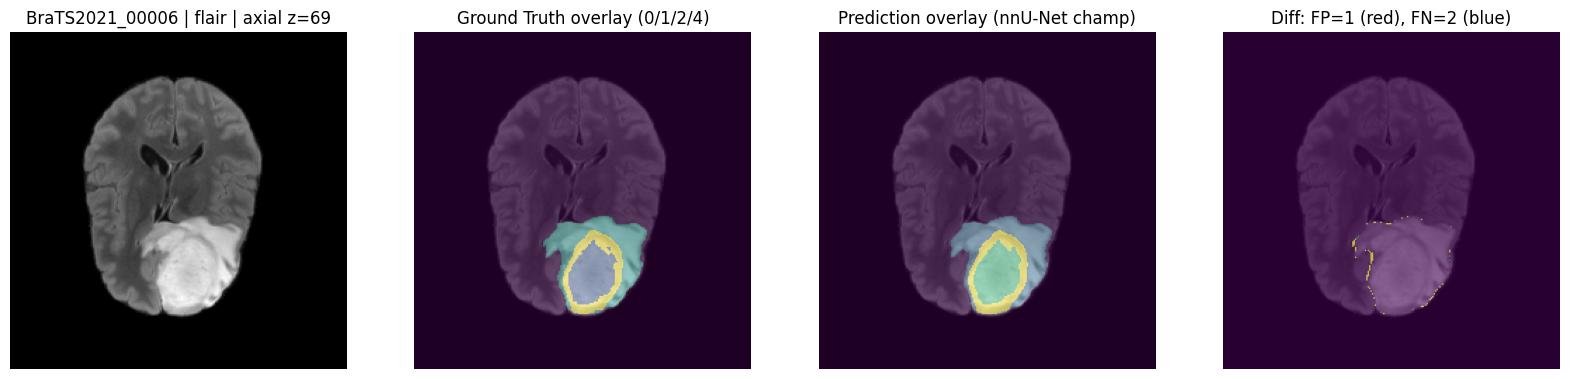

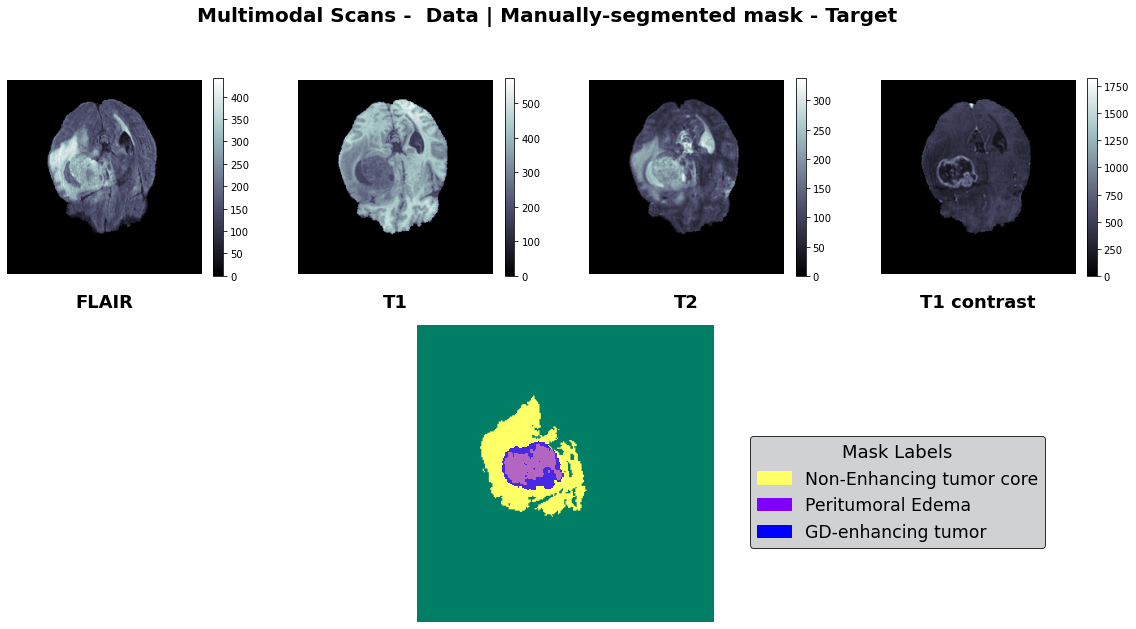

In [10]:
import os, numpy as np, nibabel as nib
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# ====== paths（Windows，移出 temp） ======
DATA_DIR = "C:/Users/kelvin/Downloads/archive/BraTS2021_Training_Data"        # 原始 BraTS 解压目录
OUT_DIR  = "C:/Users/kelvin/Downloads/brats_workspace/kaist_pred_A"           # nnUNet 推理输出目录（或 ensemble 输出）
mods = ["t1","t1ce","t2","flair"]

cases = sorted([d for d in os.listdir(DATA_DIR) if d.startswith("BraTS2021_")])
print("cases:", len(cases))

pid = cases[0]  # 想换病例就改这里
cdir = os.path.join(DATA_DIR, pid)
print("Visualizing case:", pid)

# ====== load 4-modality volume ======
vols = []
for m in mods:
    p = os.path.join(cdir, f"{pid}_{m}.nii.gz")
    nii = nib.load(p)
    vols.append(nii.get_fdata().astype(np.float32))
vol = np.stack(vols, axis=0)  # (4,H,W,D)

# ====== load nnUNet prediction ======
seg_path = os.path.join(OUT_DIR, f"{pid}.nii.gz")
seg = nib.load(seg_path).get_fdata().astype(np.uint8)  # (H,W,D)

C, H, W, D = vol.shape

# ====== widgets ======
mod_dd = widgets.Dropdown(options=mods, value="flair", description="Modality:")
view_dd = widgets.Dropdown(
    options=["axial (Z)", "coronal (Y)", "sagittal (X)"],
    value="axial (Z)", description="View:"
)
slice_slider = widgets.IntSlider(min=0, max=D-1, step=1, value=D//2, description="Slice:")
overlay_chk = widgets.Checkbox(value=True, description="Overlay mask")
alpha_slider = widgets.FloatSlider(min=0.0, max=1.0, step=0.05, value=0.45, description="Alpha:")

def update_slice_range(*args):
    view = view_dd.value
    if view.startswith("axial"):
        slice_slider.max = D-1
    elif view.startswith("coronal"):
        slice_slider.max = W-1
    else:
        slice_slider.max = H-1
    slice_slider.value = min(slice_slider.value, slice_slider.max)

view_dd.observe(update_slice_range, names="value")
update_slice_range()

# ====== render function ======
def show_slice(modality, view, slice_idx, overlay, alpha):
    c = mods.index(modality)
    vol_c = vol[c]  # (H,W,D)

    plt.figure(figsize=(7,7))
    if view.startswith("axial"):
        z = slice_idx
        img2d = vol_c[:, :, z]
        msk2d = seg[:, :, z]
        title = f"{pid} | {modality} axial z={z}/{D-1}"
    elif view.startswith("coronal"):
        y = slice_idx
        img2d = vol_c[:, y, :]
        msk2d = seg[:, y, :]
        title = f"{pid} | {modality} coronal y={y}/{W-1}"
    else:
        x = slice_idx
        img2d = vol_c[x, :, :]
        msk2d = seg[x, :, :]
        title = f"{pid} | {modality} sagittal x={x}/{H-1}"

    # MRI
    plt.imshow(img2d.T, cmap="gray", origin="lower")

    # overlay seg (0/1/2/4 多类自动着色)
    if overlay:
        plt.imshow(msk2d.T, alpha=alpha, origin="lower")

    plt.title(title)
    plt.axis("off")
    plt.show()

    u, cts = np.unique(msk2d, return_counts=True)
    print("Labels in this slice:", dict(zip(u.tolist(), cts.tolist())))
    print("Label meaning: 0=bg, 1=NCR/NET, 2=ED, 4=ET")

ui = widgets.VBox([
    widgets.HBox([mod_dd, view_dd]),
    widgets.HBox([slice_slider, overlay_chk, alpha_slider])
])
out = widgets.interactive_output(
    show_slice,
    {"modality": mod_dd, "view": view_dd, "slice_idx": slice_slider,
     "overlay": overlay_chk, "alpha": alpha_slider}
)
display(ui, out)

cases: 1251
Visualizing case: BraTS2021_00000


Output()

In [2]:
# Export nnU-Net predictions to .npy for Unreal Engine ingest
# - Loads each predicted NIfTI from OUT_DIR
# - Writes a .npy with shape (H,W,D) of uint8 labels
# - Saves under OUT_DIR_npy, file name matches case id
# Label meaning: 0=bg, 1=NCR/NET, 2=ED, 4=ET
import os, glob, numpy as np, nibabel as nib

OUT_DIR = r"C:/Users/kelvin/Downloads/brats_workspace/kaist_pred_A"  # predicted .nii.gz from nnU-Net
OUT_DIR_NPY = OUT_DIR + '_npy'
os.makedirs(OUT_DIR_NPY, exist_ok=True)

pred_files = sorted(glob.glob(os.path.join(OUT_DIR, 'BraTS2021_*.nii.gz')))
if len(pred_files) == 0:
    raise RuntimeError(f'No prediction files found under {OUT_DIR}')

print(f'Found {len(pred_files)} prediction volumes. Writing npy to {OUT_DIR_NPY}')
for p in pred_files:
    case_id = os.path.basename(p).replace('.nii.gz','')
    nii = nib.load(p)
    data = nii.get_fdata().astype(np.uint8)  # labels
    out_path = os.path.join(OUT_DIR_NPY, case_id + '.npy')
    np.save(out_path, data)
    print(f'Saved {out_path} | shape={data.shape} dtype={data.dtype}')

print('Done. Unreal can load npy with numpy or convert to desired UE asset pipeline.')

Found 100 prediction volumes. Writing npy to C:/Users/kelvin/Downloads/brats_workspace/kaist_pred_A_npy
Saved C:/Users/kelvin/Downloads/brats_workspace/kaist_pred_A_npy\BraTS2021_00000.npy | shape=(240, 240, 155) dtype=uint8
Saved C:/Users/kelvin/Downloads/brats_workspace/kaist_pred_A_npy\BraTS2021_00002.npy | shape=(240, 240, 155) dtype=uint8
Saved C:/Users/kelvin/Downloads/brats_workspace/kaist_pred_A_npy\BraTS2021_00003.npy | shape=(240, 240, 155) dtype=uint8
Saved C:/Users/kelvin/Downloads/brats_workspace/kaist_pred_A_npy\BraTS2021_00005.npy | shape=(240, 240, 155) dtype=uint8
Saved C:/Users/kelvin/Downloads/brats_workspace/kaist_pred_A_npy\BraTS2021_00006.npy | shape=(240, 240, 155) dtype=uint8
Saved C:/Users/kelvin/Downloads/brats_workspace/kaist_pred_A_npy\BraTS2021_00008.npy | shape=(240, 240, 155) dtype=uint8
Saved C:/Users/kelvin/Downloads/brats_workspace/kaist_pred_A_npy\BraTS2021_00009.npy | shape=(240, 240, 155) dtype=uint8
Saved C:/Users/kelvin/Downloads/brats_workspace/k

In [3]:
import nibabel as nib
import glob, os

OUT_DIR = r"C:/Users/kelvin/Downloads/brats_workspace/kaist_pred_A"
p = sorted(glob.glob(os.path.join(OUT_DIR, "BraTS2021_*.nii.gz")))[0]
nii = nib.load(p)
print("file:", p)
print("shape:", nii.shape)                 # (H, W, D)
print("voxel spacing:", nii.header.get_zooms())  # (sx, sy, sz)

file: C:/Users/kelvin/Downloads/brats_workspace/kaist_pred_A\BraTS2021_00000.nii.gz
shape: (240, 240, 155)
voxel spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))


In [4]:
# Batch export: pack each predicted label volume into a 2D atlas PNG (for Unreal)
# - Input: OUT_DIR/BraTS2021_*.nii.gz (uint labels: 0/1/2/4)
# - Output: OUT_DIR_atlas/{case_id}_label_atlas.png
# Orientation: matches your notebook display style (slice.T + origin=lower)
import os, math, glob, numpy as np, nibabel as nib

# imageio is used to save PNG
try:
    import imageio.v2 as imageio
except Exception:
    # In Jupyter, this will install imageio if missing
    try:
        get_ipython().system('pip -q install imageio')
        import imageio.v2 as imageio
    except Exception as e:
        raise RuntimeError('imageio is required to write PNG. Please install imageio.') from e

OUT_DIR = r"C:/Users/kelvin/Downloads/brats_workspace/kaist_pred_A"
OUT_DIR_ATLAS = OUT_DIR + '_atlas'
os.makedirs(OUT_DIR_ATLAS, exist_ok=True)

def save_label_atlas_from_nii(nii_path, out_png, cols=16, rows=None):
    data = nib.load(nii_path).get_fdata().astype(np.uint8)  # (H,W,D)
    H, W, D = data.shape
    if rows is None:
        rows = int(math.ceil(D / cols))
    if cols * rows < D:
        raise ValueError(f'cols*rows must cover D slices: cols={cols}, rows={rows}, D={D}')

    # After transpose, each slice becomes (W,H)
    slice_h, slice_w = W, H
    atlas = np.zeros((rows * slice_h, cols * slice_w), dtype=np.uint8)

    for z in range(D):
        r = z // cols
        c = z % cols
        sl = data[:, :, z]
        # Equivalent to: plt.imshow(sl.T, origin='lower')
        sl = np.flipud(sl.T)
        y0 = r * slice_h
        x0 = c * slice_w
        atlas[y0:y0+slice_h, x0:x0+slice_w] = sl

    imageio.imwrite(out_png, atlas)
    return atlas.shape, atlas.dtype, (H, W, D)

pred_files = sorted(glob.glob(os.path.join(OUT_DIR, 'BraTS2021_*.nii.gz')))
if len(pred_files) == 0:
    raise RuntimeError(f'No prediction files found under {OUT_DIR}')

print(f'Found {len(pred_files)} predictions. Writing atlas PNGs to: {OUT_DIR_ATLAS}')
for nii_path in pred_files:
    case_id = os.path.basename(nii_path).replace('.nii.gz', '')
    out_png = os.path.join(OUT_DIR_ATLAS, f'{case_id}_label_atlas.png')
    atlas_shape, atlas_dtype, vol_shape = save_label_atlas_from_nii(nii_path, out_png, cols=16, rows=None)
    print(f'{case_id}: vol={vol_shape} -> atlas={atlas_shape} dtype={atlas_dtype} -> {out_png}')

print('Done.')

Found 100 predictions. Writing atlas PNGs to: C:/Users/kelvin/Downloads/brats_workspace/kaist_pred_A_atlas
BraTS2021_00000: vol=(240, 240, 155) -> atlas=(2400, 3840) dtype=uint8 -> C:/Users/kelvin/Downloads/brats_workspace/kaist_pred_A_atlas\BraTS2021_00000_label_atlas.png
BraTS2021_00002: vol=(240, 240, 155) -> atlas=(2400, 3840) dtype=uint8 -> C:/Users/kelvin/Downloads/brats_workspace/kaist_pred_A_atlas\BraTS2021_00002_label_atlas.png
BraTS2021_00003: vol=(240, 240, 155) -> atlas=(2400, 3840) dtype=uint8 -> C:/Users/kelvin/Downloads/brats_workspace/kaist_pred_A_atlas\BraTS2021_00003_label_atlas.png
BraTS2021_00005: vol=(240, 240, 155) -> atlas=(2400, 3840) dtype=uint8 -> C:/Users/kelvin/Downloads/brats_workspace/kaist_pred_A_atlas\BraTS2021_00005_label_atlas.png
BraTS2021_00006: vol=(240, 240, 155) -> atlas=(2400, 3840) dtype=uint8 -> C:/Users/kelvin/Downloads/brats_workspace/kaist_pred_A_atlas\BraTS2021_00006_label_atlas.png
BraTS2021_00008: vol=(240, 240, 155) -> atlas=(2400, 3840)